In [1]:
# ============================================================================
# IMPORT CÁC THƯ VIỆN CẦN THIẾT CHO XAI-RL FRAMEWORK
# ============================================================================

# 1. System & Path
import sys
import os
sys.path.append('d:\\NCKH\\SARSA_FinancialRL')

# 2. Data Processing
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 3. Deep Learning - PyTorch
import torch
from torch import nn
import torch.nn.functional as F

# 4. Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style cho plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 5. XAI Libraries - CHỈ DÙNG SHAP
try:
    import shap
    print("✓ SHAP available")
except ImportError:
    print("⚠ SHAP not installed - will install when needed")

# 6. Project-specific Imports
from agents.d_sarsa.d_sarsa import Qsa
from environments.stock_trading_env.mdp import StockTradingMDP
from data.data_provider.library_extracted.vnstock.VNStockDataProvider import VNStockDataProvider
from data.data_processor.feature_engineer import engineer_stat as es

# 7. Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("="*80)
print("✓ Tất cả thư viện đã được import thành công!")
print("="*80)
print("\n🎯 XAI-RL Framework - 3 Phương pháp độc lập:")
print("  [1] RDX  - Reward Decomposition (weights từ domain knowledge)")
print("  [2] MSX  - Multi-Step Explanation (trajectory analysis)")
print("  [3] SHAP - Feature Attribution (Shapley values)")
print("\n📊 Deep RL Agent:")
print("  • Qsa:              Q-network (input=7, output=11)")
print("  • StockTradingMDP:  Environment cho stock trading")
print("  • VNStockData:      Data provider cho VN market")
print("\nReady to analyze SARSA agent! 🚀")
print("="*80)

✓ SHAP available


✓ Tất cả thư viện đã được import thành công!

🎯 XAI-RL Framework - 3 Phương pháp độc lập:
  [1] RDX  - Reward Decomposition (weights từ domain knowledge)
  [2] MSX  - Multi-Step Explanation (trajectory analysis)
  [3] SHAP - Feature Attribution (Shapley values)

📊 Deep RL Agent:
  • Qsa:              Q-network (input=7, output=11)
  • StockTradingMDP:  Environment cho stock trading
  • VNStockData:      Data provider cho VN market

Ready to analyze SARSA agent! 🚀


In [2]:
# 1.1. Load model SARSA
qsa = Qsa(input_size=7, num_classes=11)
model_path_acb_phase_1 = 'd:\\NCKH\\SARSA_FinancialRL\\models\\sarsa_acb_phase_3.pth'
model_path_fpt_phase_1 = 'd:\\NCKH\\SARSA_FinancialRL\\models\\sarsa_fpt_phase_3.pth'
model_path_gas_phase_1 = 'd:\\NCKH\\SARSA_FinancialRL\\models\\sarsa_gas_phase_3.pth'
model_path_hpg_phase_1 = 'd:\\NCKH\\SARSA_FinancialRL\\models\\sarsa_hpg_phase_3.pth'
model_path_ssi_phase_1 = 'd:\\NCKH\\SARSA_FinancialRL\\models\\sarsa_ssi_phase_3.pth'
model_path_vcb_phase_1 = 'd:\\NCKH\\SARSA_FinancialRL\\models\\sarsa_vcb_phase_3.pth'

# # 1.2. Load dữ liệu 
# provider = VNStockDataProvider()
# print("\nĐang lấy dữ liệu từ vnstock...")
# df_raw = provider.get_ohlcv_data('SSI', '2021-12-14', '2024-12-31')
# print(f"✓ Đã lấy {len(df_raw)} dòng dữ liệu")

# # 1.3. Xử lý dữ liệu và thêm technical indicators
# df_processed = df_raw.copy()
# df_processed.rename(columns={'date': 'time'}, inplace=True)
# df_processed['time'] = pd.to_datetime(df_processed['time']).dt.strftime('%d/%m/%Y')
# df_processed = es.add_technical_indicators(df_processed, start_date= '01/01/2022')
# print(f"✓ Đã thêm technical indicators: {df_processed.shape}")

df_processed_test_ACB = pd.read_csv('D:\\NCKH\\SARSA_FinancialRL\\data\\data_storer\\data_research\\test\\test_ACB_phase_3.csv')
df_processed_test_ACB.rename(columns={'date': 'time'}, inplace=True)
df_processed_test_ACB['time'] = pd.to_datetime(df_processed_test_ACB['time']).dt.strftime('%d/%m/%Y')

df_processed_test_FPT = pd.read_csv('D:\\NCKH\\SARSA_FinancialRL\\data\\data_storer\\data_research\\test\\test_FPT_phase_3.csv')
df_processed_test_FPT.rename(columns={'date': 'time'}, inplace=True)
df_processed_test_FPT['time'] = pd.to_datetime(df_processed_test_FPT['time']).dt.strftime('%d/%m/%Y')
    
df_processed_test_GAS = pd.read_csv('D:\\NCKH\\SARSA_FinancialRL\\data\\data_storer\\data_research\\test\\test_GAS_phase_3.csv')
df_processed_test_GAS.rename(columns={'date': 'time'}, inplace=True)
df_processed_test_GAS['time'] = pd.to_datetime(df_processed_test_GAS['time']).dt.strftime('%d/%m/%Y')

df_processed_test_HPG = pd.read_csv('D:\\NCKH\\SARSA_FinancialRL\\data\\data_storer\\data_research\\test\\test_HPG_phase_3.csv')
df_processed_test_HPG.rename(columns={'date': 'time'}, inplace=True)
df_processed_test_HPG['time'] = pd.to_datetime(df_processed_test_HPG['time']).dt.strftime('%d/%m/%Y')

df_processed_test_SSI = pd.read_csv('D:\\NCKH\\SARSA_FinancialRL\\data\\data_storer\\data_research\\test\\test_SSI_phase_3.csv')
df_processed_test_SSI.rename(columns={'date': 'time'}, inplace=True)
df_processed_test_SSI['time'] = pd.to_datetime(df_processed_test_SSI['time']).dt.strftime('%d/%m/%Y')

df_processed_test_VCB = pd.read_csv('D:\\NCKH\\SARSA_FinancialRL\\data\\data_storer\\data_research\\test\\test_VCB_phase_3.csv')
df_processed_test_VCB.rename(columns={'date': 'time'}, inplace=True)
df_processed_test_VCB['time'] = pd.to_datetime(df_processed_test_VCB['time']).dt.strftime('%d/%m/%Y')

# Ghép dữ liệu: train trước rồi đến test (theo thời gian) thay vì dùng toán tử '+'
# df_processed = pd.concat([df_processed_train, df_processed_test], ignore_index=True)
# Đảm bảo thứ tự thời gian tăng dần nếu chưa chắc chắn
# _df_time = pd.to_datetime(df_processed['time'], format='%d/%m/%Y')
# df_processed = df_processed.assign(_time=_df_time).sort_values('_time').drop(columns=['_time']).reset_index(drop=True)
# print(f"✓ Merged train+test: {df_processed.shape} (train={df_processed_train.shape}, test={df_processed_test.shape})")
# print(f"  Time range: {df_processed['time'].iloc[0]} -> {df_processed['time'].iloc[-1]}")


In [3]:
if os.path.exists(model_path_acb_phase_1):
    state_dict = torch.load(model_path_acb_phase_1, map_location=torch.device('cpu'))
    qsa.load_state_dict(state_dict)
    qsa.eval()
    print(f"✓ Model loaded: {model_path_acb_phase_1}")
else:
    print(f"✗ Model not found: {model_path_acb_phase_1}")

✓ Model loaded: d:\NCKH\SARSA_FinancialRL\models\sarsa_acb_phase_3.pth


In [4]:
mdp_ACB = StockTradingMDP(balance_init=1000, k=5, min_balance=-100)

def pi_deep(s, eps=0.0, greedy=True):
    with torch.no_grad():
        out_qsa = qsa(torch.Tensor(s).float()).squeeze()
        action = out_qsa.argmax().item() - 5
    return action

# State ban đầu
first_row_ACB = df_processed_test_ACB.iloc[0]
state_init_ACB = [
    float(first_row_ACB['close']),
    mdp_ACB.balance_init,
    0,
    float(first_row_ACB['MACD']),
    float(first_row_ACB['RSI']),
    float(first_row_ACB['CCI']),
    float(first_row_ACB['ADX'])
]

# Chạy simulation
print("\nĐang chạy simulation...")
states_ACB, rewards_ACB, actions_ACB = mdp_ACB.simulate(
    df_processed_test_ACB[1:].reset_index(drop=True), 
    state_init_ACB, 
    pi_deep, 
    greedy=True, 
    eps=0.0
)

print(f"✓ Simulation hoàn tất: {len(states_ACB)} states, {len(actions_ACB)} actions")
print(f"  Total reward: {sum(rewards_ACB):.2f}")
print(f"  Final portfolio: ${states_ACB[-1][1] + states_ACB[-1][0]*states_ACB[-1][2]:.2f}")


Đang chạy simulation...
✓ Simulation hoàn tất: 250 states, 249 actions
  Total reward: 113.24
  Final portfolio: $1113.24


In [5]:
# Chuẩn bị dữ liệu X và hàm dự đoán cho SHAP
import importlib
if importlib.util.find_spec('shap') is None:
    import sys, subprocess
    print('Đang cài đặt shap...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap'])
    import shap
else:
    import shap

# Ma trận trạng thái từ mô phỏng
X_ACB = np.array(states_ACB, dtype=np.float32)
feature_names = ['close','balance','position','MACD','RSI','CCI','ADX']

# Hàm dự đoán: trả về Q-value của hành động greedy (argmax) cho mỗi hàng
def predict_q_greedy(X_batch):
    X_t = torch.tensor(X_batch, dtype=torch.float32)
    with torch.no_grad():
        q = qsa(X_t)  # [N, 11]
        # Lấy Q-value theo hành động có Q lớn nhất cho từng hàng
        ai = torch.argmax(q, dim=1)  # [N]
        out = q.gather(dim=1, index=ai.view(-1,1)).squeeze(1)  # [N]
        return out.cpu().numpy().astype(np.float32)

print(f'X shape: {X_ACB.shape}')

X shape: (250, 7)


In [6]:
# Tính SHAP values với KernelExplainer (có thể mất vài phút với dữ liệu lớn)
# Chọn background nhỏ để tăng tốc
rng = np.random.default_rng(42)
bg_idx_ACB = rng.choice(len(X_ACB), size=min(3000, len(X_ACB)), replace=False)
X_bg_ACB = X_ACB[bg_idx_ACB]

# Chọn sample để giải thích (ví dụ 300 bước gần nhất hoặc toàn bộ nếu ít hơn)
sample_len_ACB = len(X_ACB)
X_sample_ACB = X_ACB[-sample_len_ACB:]

explainer_ACB = shap.KernelExplainer(predict_q_greedy, X_bg_ACB)
shap_values_ACB = explainer_ACB.shap_values(X_sample_ACB, nsamples='auto')
print('✓ Đã tính xong SHAP values cho sample:', len(X_sample_ACB))

Using 250 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/250 [00:00<?, ?it/s]

✓ Đã tính xong SHAP values cho sample: 250


In [7]:
if os.path.exists(model_path_fpt_phase_1):
    state_dict = torch.load(model_path_fpt_phase_1, map_location=torch.device('cpu'))
    qsa.load_state_dict(state_dict)
    qsa.eval()
    print(f"✓ Model loaded: {model_path_fpt_phase_1}")
else:
    print(f"✗ Model not found: {model_path_fpt_phase_1}")

mdp_FPT = StockTradingMDP(balance_init=1000, k=5, min_balance=-100)

def pi_deep(s, eps=0.0, greedy=True):
    with torch.no_grad():
        out_qsa = qsa(torch.Tensor(s).float()).squeeze()
        action = out_qsa.argmax().item() - 5
    return action

# State ban đầu
first_row_FPT = df_processed_test_FPT.iloc[0]
state_init_FPT = [
    float(first_row_FPT['close']),
    mdp_FPT.balance_init,
    0,
    float(first_row_FPT['MACD']),
    float(first_row_FPT['RSI']),
    float(first_row_FPT['CCI']),
    float(first_row_FPT['ADX'])
]

# Chạy simulation
print("\nĐang chạy simulation...")
states_FPT, rewards_FPT, actions_FPT = mdp_FPT.simulate(
    df_processed_test_FPT[1:].reset_index(drop=True), 
    state_init_FPT, 
    pi_deep, 
    greedy=True, 
    eps=0.0
)

print(f"✓ Simulation hoàn tất: {len(states_FPT)} states, {len(actions_FPT)} actions")
print(f"  Total reward: {sum(rewards_FPT):.2f}")
print(f"  Final portfolio: ${states_FPT[-1][1] + states_FPT[-1][0]*states_FPT[-1][2]:.2f}")

# Ma trận trạng thái từ mô phỏng
X_FPT = np.array(states_FPT, dtype=np.float32)
feature_names = ['close','balance','position','MACD','RSI','CCI','ADX']

# Hàm dự đoán: trả về Q-value của hành động greedy (argmax) cho mỗi hàng
def predict_q_greedy(X_batch):
    X_t = torch.tensor(X_batch, dtype=torch.float32)
    with torch.no_grad():
        q = qsa(X_t)  # [N, 11]
        # Lấy Q-value theo hành động có Q lớn nhất cho từng hàng
        ai = torch.argmax(q, dim=1)  # [N]
        out = q.gather(dim=1, index=ai.view(-1,1)).squeeze(1)  # [N]
        return out.cpu().numpy().astype(np.float32)

print(f'X shape: {X_FPT.shape}')

# Tính SHAP values với KernelExplainer (có thể mất vài phút với dữ liệu lớn)

bg_idx_FPT = rng.choice(len(X_FPT), size=min(3000, len(X_FPT)), replace=False)
X_bg_FPT = X_FPT[bg_idx_FPT]

# Chọn sample để giải thích (ví dụ 300 bước gần nhất hoặc toàn bộ nếu ít hơn)
sample_len_FPT = len(X_FPT)
X_sample_FPT = X_FPT[-sample_len_FPT:]

explainer_FPT = shap.KernelExplainer(predict_q_greedy, X_bg_FPT)
shap_values_FPT = explainer_FPT.shap_values(X_sample_FPT, nsamples='auto')
print('✓ Đã tính xong SHAP values cho sample:', len(X_sample_FPT))

Using 250 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


✓ Model loaded: d:\NCKH\SARSA_FinancialRL\models\sarsa_fpt_phase_3.pth

Đang chạy simulation...
✓ Simulation hoàn tất: 250 states, 249 actions
  Total reward: 609.94
  Final portfolio: $1609.94
X shape: (250, 7)


  0%|          | 0/250 [00:00<?, ?it/s]

✓ Đã tính xong SHAP values cho sample: 250


In [8]:
if os.path.exists(model_path_gas_phase_1):
    state_dict = torch.load(model_path_gas_phase_1, map_location=torch.device('cpu'))
    qsa.load_state_dict(state_dict)
    qsa.eval()
    print(f"✓ Model loaded: {model_path_gas_phase_1}")
else:
    print(f"✗ Model not found: {model_path_gas_phase_1}")

mdp_GAS = StockTradingMDP(balance_init=1000, k=5, min_balance=-100)
def pi_deep(s, eps=0.0, greedy=True):
    with torch.no_grad():
        out_qsa = qsa(torch.Tensor(s).float()).squeeze()
        action = out_qsa.argmax().item() - 5
    return action

# State ban đầu
first_row_GAS = df_processed_test_GAS.iloc[0]
state_init_GAS = [
    float(first_row_GAS['close']),
    mdp_GAS.balance_init,
    0,
    float(first_row_GAS['MACD']),
    float(first_row_GAS['RSI']),
    float(first_row_GAS['CCI']),
    float(first_row_GAS['ADX'])
]

# Chạy simulation
print("\nĐang chạy simulation...")
states_GAS, rewards_GAS, actions_GAS = mdp_GAS.simulate(
    df_processed_test_GAS[1:].reset_index(drop=True), 
    state_init_GAS, 
    pi_deep, 
    greedy=True, 
    eps=0.0
)

print(f"✓ Simulation hoàn tất: {len(states_GAS)} states, {len(actions_GAS)} actions")
print(f"  Total reward: {sum(rewards_GAS):.2f}")
print(f"  Final portfolio: ${states_GAS[-1][1] + states_GAS[-1][0]*states_GAS[-1][2]:.2f}")

# Ma trận trạng thái từ mô phỏng
X_GAS = np.array(states_GAS, dtype=np.float32)
feature_names = ['close','balance','position','MACD','RSI','CCI','ADX']

# Hàm dự đoán: trả về Q-value của hành động greedy (argmax) cho mỗi hàng
def predict_q_greedy(X_batch):
    X_t = torch.tensor(X_batch, dtype=torch.float32)
    with torch.no_grad():
        q = qsa(X_t)  # [N, 11]
        # Lấy Q-value theo hành động có Q lớn nhất cho từng hàng
        ai = torch.argmax(q, dim=1)  # [N]
        out = q.gather(dim=1, index=ai.view(-1,1)).squeeze(1)  # [N]
        return out.cpu().numpy().astype(np.float32)

print(f'X shape: {X_GAS.shape}')

# Tính SHAP values với KernelExplainer (có thể mất vài phút với dữ liệu lớn)

bg_idx_GAS = rng.choice(len(X_GAS), size=min(3000, len(X_GAS)), replace=False)
X_bg_GAS = X_GAS[bg_idx_GAS]

# Chọn sample để giải thích (ví dụ 300 bước gần nhất hoặc toàn bộ nếu ít hơn)
sample_len_GAS = len(X_GAS)
X_sample_GAS = X_GAS[-sample_len_GAS:]
explainer_GAS = shap.KernelExplainer(predict_q_greedy, X_bg_GAS)
shap_values_GAS = explainer_GAS.shap_values(X_sample_GAS, nsamples='auto')
print('✓ Đã tính xong SHAP values cho sample:', len(X_sample_GAS))

Using 250 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


✓ Model loaded: d:\NCKH\SARSA_FinancialRL\models\sarsa_gas_phase_3.pth

Đang chạy simulation...
✓ Simulation hoàn tất: 250 states, 249 actions
  Total reward: 18.76
  Final portfolio: $1018.76
X shape: (250, 7)


  0%|          | 0/250 [00:00<?, ?it/s]

✓ Đã tính xong SHAP values cho sample: 250


In [9]:
if os.path.exists(model_path_hpg_phase_1):
    state_dict = torch.load(model_path_hpg_phase_1, map_location=torch.device('cpu'))
    qsa.load_state_dict(state_dict)
    qsa.eval()
    print(f"✓ Model loaded: {model_path_hpg_phase_1}")
else:
    print(f"✗ Model not found: {model_path_hpg_phase_1}")

mdp_HPG = StockTradingMDP(balance_init=1000, k=5, min_balance=-100)

def pi_deep(s, eps=0.0, greedy=True):
    with torch.no_grad():
        out_qsa = qsa(torch.Tensor(s).float()).squeeze()
        action = out_qsa.argmax().item() - 5
    return action

# State ban đầu
first_row_HPG = df_processed_test_HPG.iloc[0]
state_init_HPG = [
    float(first_row_HPG['close']),
    mdp_HPG.balance_init,
    0,
    float(first_row_HPG['MACD']),
    float(first_row_HPG['RSI']),
    float(first_row_HPG['CCI']),
    float(first_row_HPG['ADX'])
]

# Chạy simulation
print("\nĐang chạy simulation...")
states_HPG, rewards_HPG, actions_HPG = mdp_HPG.simulate(
    df_processed_test_HPG[1:].reset_index(drop=True), 
    state_init_HPG, 
    pi_deep, 
    greedy=True, 
    eps=0.0
)

print(f"✓ Simulation hoàn tất: {len(states_HPG)} states, {len(actions_HPG)} actions")
print(f"  Total reward: {sum(rewards_HPG):.2f}")
print(f"  Final portfolio: ${states_HPG[-1][1] + states_HPG[-1][0]*states_HPG[-1][2]:.2f}")

# Ma trận trạng thái từ mô phỏng
X_HPG = np.array(states_HPG, dtype=np.float32)
feature_names = ['close','balance','position','MACD','RSI','CCI','ADX']

# Hàm dự đoán: trả về Q-value của hành động greedy (argmax) cho mỗi hàng
def predict_q_greedy(X_batch):
    X_t = torch.tensor(X_batch, dtype=torch.float32)
    with torch.no_grad():
        q = qsa(X_t)  # [N, 11]
        # Lấy Q-value theo hành động có Q lớn nhất cho từng hàng
        ai = torch.argmax(q, dim=1)  # [N]
        out = q.gather(dim=1, index=ai.view(-1,1)).squeeze(1)  # [N]
        return out.cpu().numpy().astype(np.float32)

print(f'X shape: {X_HPG.shape}')

# Tính SHAP values với KernelExplainer (có thể mất vài phút với dữ liệu lớn)

bg_idx_HPG = rng.choice(len(X_HPG), size=min(3000, len(X_HPG)), replace=False)
X_bg_HPG = X_HPG[bg_idx_HPG]

# Chọn sample để giải thích (ví dụ 300 bước gần nhất hoặc toàn bộ nếu ít hơn)
sample_len_HPG = len(X_HPG)
X_sample_HPG = X_HPG[-sample_len_HPG:]

explainer_HPG = shap.KernelExplainer(predict_q_greedy, X_bg_HPG)
shap_values_HPG = explainer_HPG.shap_values(X_sample_HPG, nsamples='auto')
print('✓ Đã tính xong SHAP values cho sample:', len(X_sample_HPG))

Using 250 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


✓ Model loaded: d:\NCKH\SARSA_FinancialRL\models\sarsa_hpg_phase_3.pth

Đang chạy simulation...
✓ Simulation hoàn tất: 250 states, 249 actions
  Total reward: 427.47
  Final portfolio: $1427.47
X shape: (250, 7)


  0%|          | 0/250 [00:00<?, ?it/s]

✓ Đã tính xong SHAP values cho sample: 250


In [10]:
if os.path.exists(model_path_ssi_phase_1):
    state_dict = torch.load(model_path_ssi_phase_1, map_location=torch.device('cpu'))
    qsa.load_state_dict(state_dict)
    qsa.eval()
    print(f"✓ Model loaded: {model_path_ssi_phase_1}")
else:
    print(f"✗ Model not found: {model_path_ssi_phase_1}")

mdp_SSI = StockTradingMDP(balance_init=1000, k=5, min_balance=-100)

def pi_deep(s, eps=0.0, greedy=True):
    with torch.no_grad():
        out_qsa = qsa(torch.Tensor(s).float()).squeeze()
        action = out_qsa.argmax().item() - 5
    return action

# State ban đầu
first_row_SSI = df_processed_test_SSI.iloc[0]
state_init_SSI = [
    float(first_row_SSI['close']),
    mdp_SSI.balance_init,
    0,
    float(first_row_SSI['MACD']),
    float(first_row_SSI['RSI']),
    float(first_row_SSI['CCI']),
    float(first_row_SSI['ADX'])
]

# Chạy simulation
print("\nĐang chạy simulation...")
states_SSI, rewards_SSI, actions_SSI = mdp_SSI.simulate(
    df_processed_test_SSI[1:].reset_index(drop=True), 
    state_init_SSI, 
    pi_deep, 
    greedy=True, 
    eps=0.0
)

print(f"✓ Simulation hoàn tất: {len(states_SSI)} states, {len(actions_SSI)} actions")
print(f"  Total reward: {sum(rewards_SSI):.2f}")
print(f"  Final portfolio: ${states_SSI[-1][1] + states_SSI[-1][0]*states_SSI[-1][2]:.2f}")

# Ma trận trạng thái từ mô phỏng
X_SSI = np.array(states_SSI, dtype=np.float32)
feature_names = ['close','balance','position','MACD','RSI','CCI','ADX']

# Hàm dự đoán: trả về Q-value của hành động greedy (argmax) cho mỗi hàng
def predict_q_greedy(X_batch):
    X_t = torch.tensor(X_batch, dtype=torch.float32)
    with torch.no_grad():
        q = qsa(X_t)  # [N, 11]
        # Lấy Q-value theo hành động có Q lớn nhất cho từng hàng
        ai = torch.argmax(q, dim=1)  # [N]
        out = q.gather(dim=1, index=ai.view(-1,1)).squeeze(1)  # [N]
        return out.cpu().numpy().astype(np.float32)

print(f'X shape: {X_SSI.shape}')

# Tính SHAP values với KernelExplainer (có thể mất vài phút với dữ liệu lớn)

bg_idx_SSI = rng.choice(len(X_SSI), size=min(3000, len(X_SSI)), replace=False)
X_bg_SSI = X_SSI[bg_idx_SSI]

# Chọn sample để giải thích (ví dụ 300 bước gần nhất hoặc toàn bộ nếu ít hơn)
sample_len_SSI = len(X_SSI)
X_sample_SSI = X_SSI[-sample_len_SSI:]

explainer_SSI = shap.KernelExplainer(predict_q_greedy, X_bg_SSI)
shap_values_SSI = explainer_SSI.shap_values(X_sample_SSI, nsamples='auto')
print('✓ Đã tính xong SHAP values cho sample:', len(X_sample_SSI))

Using 250 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


✓ Model loaded: d:\NCKH\SARSA_FinancialRL\models\sarsa_ssi_phase_3.pth

Đang chạy simulation...
✓ Simulation hoàn tất: 250 states, 249 actions
  Total reward: 893.87
  Final portfolio: $1893.87
X shape: (250, 7)


  0%|          | 0/250 [00:00<?, ?it/s]

✓ Đã tính xong SHAP values cho sample: 250


In [11]:
if os.path.exists(model_path_vcb_phase_1):
    state_dict = torch.load(model_path_vcb_phase_1, map_location=torch.device('cpu'))
    qsa.load_state_dict(state_dict)
    qsa.eval()
    print(f"✓ Model loaded: {model_path_vcb_phase_1}")
else:
    print(f"✗ Model not found: {model_path_vcb_phase_1}")

mdp_VCB = StockTradingMDP(balance_init=1000, k=5, min_balance=-100)

def pi_deep(s, eps=0.0, greedy=True):
    with torch.no_grad():
        out_qsa = qsa(torch.Tensor(s).float()).squeeze()
        action = out_qsa.argmax().item() - 5
    return action

# State ban đầu
first_row_VCB = df_processed_test_VCB.iloc[0]
state_init_VCB = [
    float(first_row_VCB['close']),
    mdp_VCB.balance_init,
    0,
    float(first_row_VCB['MACD']),
    float(first_row_VCB['RSI']),
    float(first_row_VCB['CCI']),
    float(first_row_VCB['ADX'])
]

# Chạy simulation
print("\nĐang chạy simulation...")
states_VCB, rewards_VCB, actions_VCB = mdp_VCB.simulate(
    df_processed_test_VCB[1:].reset_index(drop=True), 
    state_init_VCB, 
    pi_deep, 
    greedy=True, 
    eps=0.0
)

print(f"✓ Simulation hoàn tất: {len(states_VCB)} states, {len(actions_VCB)} actions")
print(f"  Total reward: {sum(rewards_VCB):.2f}")
print(f"  Final portfolio: ${states_VCB[-1][1] + states_VCB[-1][0]*states_VCB[-1][2]:.2f}")

# Ma trận trạng thái từ mô phỏng
X_VCB = np.array(states_VCB, dtype=np.float32)
feature_names = ['close','balance','position','MACD','RSI','CCI','ADX']

# Hàm dự đoán: trả về Q-value của hành động greedy (argmax) cho mỗi hàng
def predict_q_greedy(X_batch):
    X_t = torch.tensor(X_batch, dtype=torch.float32)
    with torch.no_grad():
        q = qsa(X_t)  # [N, 11]
        # Lấy Q-value theo hành động có Q lớn nhất cho từng hàng
        ai = torch.argmax(q, dim=1)  # [N]
        out = q.gather(dim=1, index=ai.view(-1,1)).squeeze(1)  # [N]
        return out.cpu().numpy().astype(np.float32)

print(f'X shape: {X_VCB.shape}')

# Tính SHAP values với KernelExplainer (có thể mất vài phút với dữ liệu lớn)

bg_idx_VCB = rng.choice(len(X_VCB), size=min(3000, len(X_VCB)), replace=False)
X_bg_VCB = X_VCB[bg_idx_VCB]

# Chọn sample để giải thích (ví dụ 300 bước gần nhất hoặc toàn bộ nếu ít hơn)
sample_len_VCB = len(X_VCB)
X_sample_VCB = X_VCB[-sample_len_VCB:]

explainer_VCB = shap.KernelExplainer(predict_q_greedy, X_bg_VCB)
shap_values_VCB = explainer_VCB.shap_values(X_sample_VCB, nsamples='auto')
print('✓ Đã tính xong SHAP values cho sample:', len(X_sample_VCB))

✓ Model loaded: d:\NCKH\SARSA_FinancialRL\models\sarsa_vcb_phase_3.pth

Đang chạy simulation...


Using 250 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


✓ Simulation hoàn tất: 250 states, 249 actions
  Total reward: 91.37
  Final portfolio: $1091.37
X shape: (250, 7)


  0%|          | 0/250 [00:00<?, ?it/s]

✓ Đã tính xong SHAP values cho sample: 250


✓ Đã xuất hình ảnh tại: D:\NCKH\SARSA_FinancialRL\Graph+Pic\SHAP_ACB_2017_2021.png


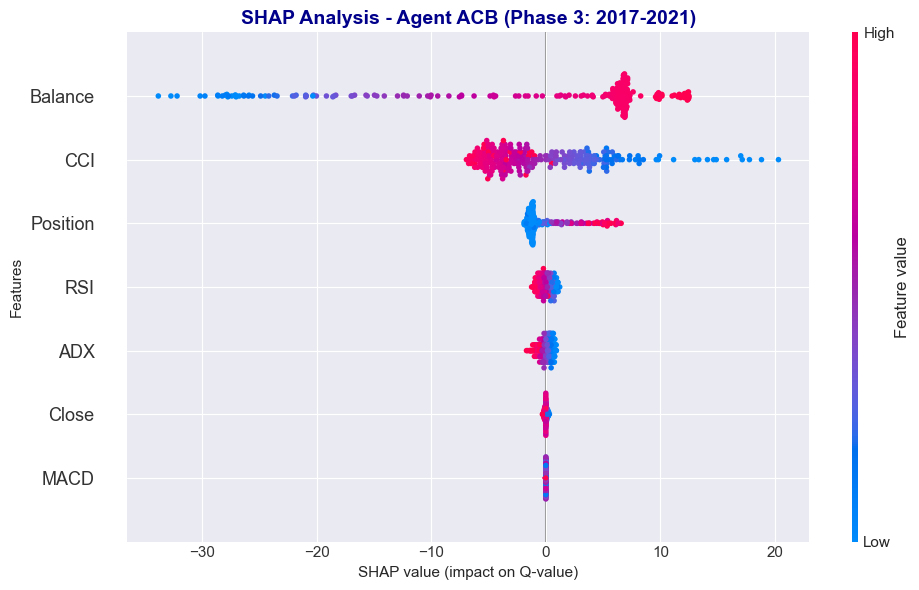

In [12]:
# Xuất biểu đồ SHAP cho 1 agent (ACB) ra file PNG
import matplotlib.pyplot as plt
import shap

# Tạo figure cho 1 agent
fig, ax = plt.subplots(figsize=(10, 6))

# Feature names
feature_names = ['Close', 'Balance', 'Position', 'MACD', 'RSI', 'CCI', 'ADX']

# Vẽ biểu đồ SHAP summary plot cho ACB
plt.sca(ax)
ax.set_title(f"SHAP Analysis - Agent ACB (Phase 3: 2017-2021)", fontsize=14, fontweight='bold', color='darkblue')

shap.summary_plot(
    shap_values_ACB, 
    X_sample_ACB, 
    feature_names=feature_names,
    max_display=7,
    show=False,
    plot_size=None,
    sort=True,
    plot_type="dot"
)

ax.set_xlabel("SHAP value (impact on Q-value)", fontsize=11)
ax.set_ylabel("Features", fontsize=11)

plt.tight_layout()

# Lưu file PNG
output_path = 'D:\\NCKH\\SARSA_FinancialRL\\Graph+Pic\\SHAP_ACB_2017_2021.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ Đã xuất hình ảnh tại: {output_path}")

# Hiển thị
plt.show()

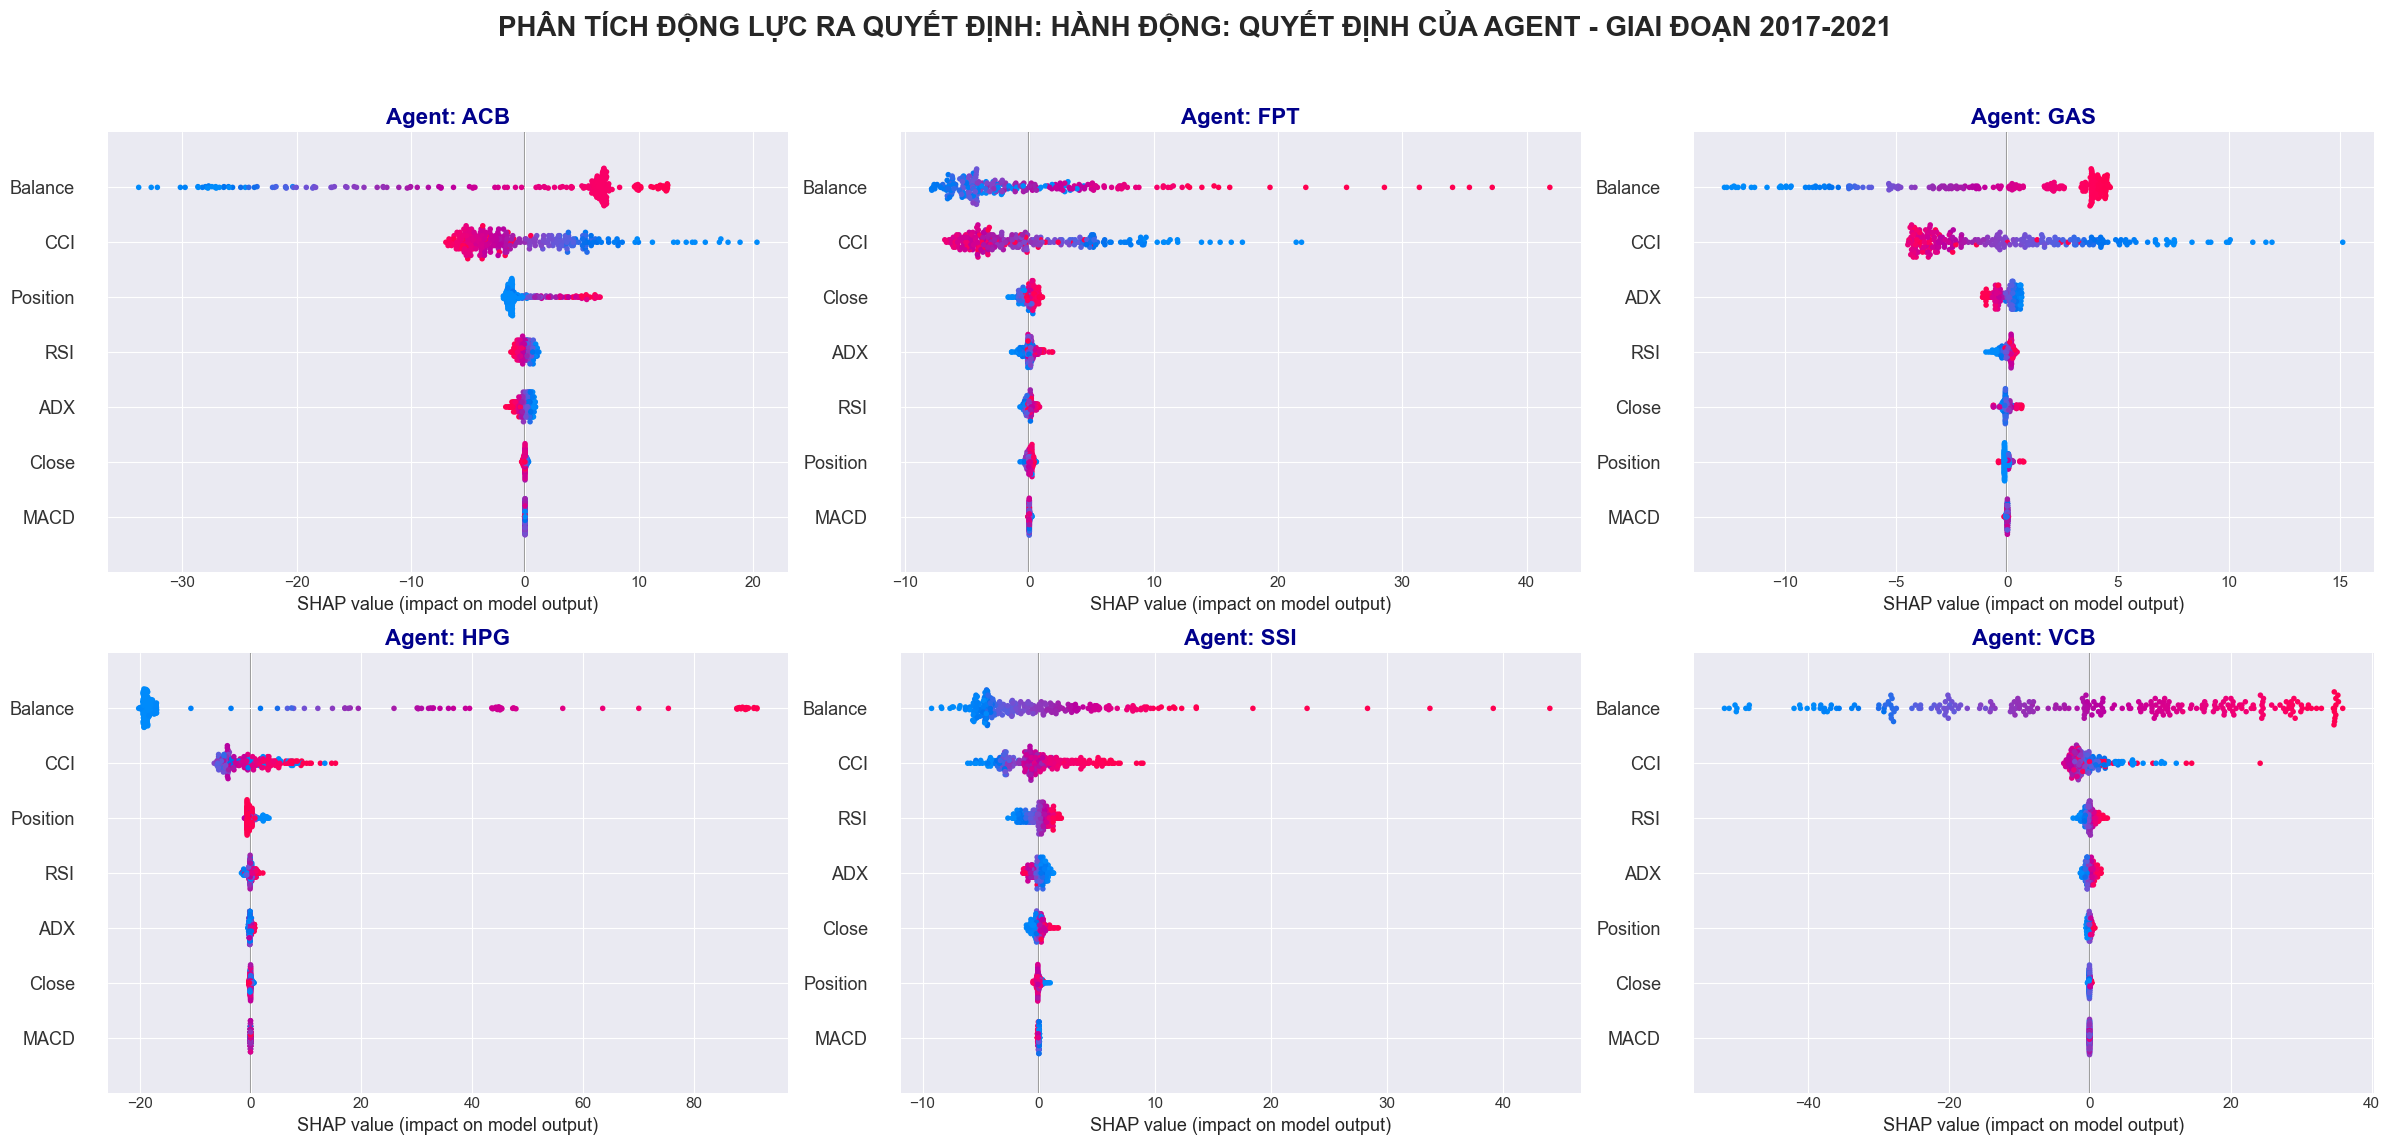

In [13]:
import matplotlib.pyplot as plt
import shap
import numpy as np

# --- HÀM VẼ BIỂU ĐỒ (ĐÃ SỬA LỖI) ---
def plot_shap_grid_for_6_agents(shap_results_dict, feature_names, action_name="Mua Mạnh (+5)", phase_name="Phase 3"):
    """
    Vẽ lưới biểu đồ SHAP Summary cho 6 agents cùng lúc.
    Tự động kiểm tra và sửa lỗi shape vector.
    """
    tickers = list(shap_results_dict.keys())
    # Cấu hình lưới 2 hàng x 3 cột
    fig = plt.figure(figsize=(24, 12))
    fig.suptitle(f"PHÂN TÍCH ĐỘNG LỰC RA QUYẾT ĐỊNH: {action_name} - {phase_name}", fontsize=20, fontweight='bold', y=0.98)
    
    for idx, ticker in enumerate(tickers):
        if idx >= 6: break
        
        ax = fig.add_subplot(2, 3, idx + 1)
        
        # Lấy dữ liệu
        shap_vals, data_vals = shap_results_dict[ticker]
        
        # --- FIX LỖI: CHUYỂN VECTOR THÀNH MATRIX ---
        # Nếu shap_vals chỉ có 1 chiều (ví dụ do lấy index [10]), reshape nó lại thành (1, Features)
        if len(np.array(shap_vals).shape) == 1:
            shap_vals = np.array(shap_vals).reshape(1, -1)
        if len(np.array(data_vals).shape) == 1:
            data_vals = np.array(data_vals).reshape(1, -1)
            
        # Vẽ biểu đồ
        plt.sca(ax)
        ax.set_title(f"Agent: {ticker}", fontsize=16, fontweight='bold', color='darkblue')
        
        try:
            shap.summary_plot(
                shap_vals, 
                data_vals, 
                feature_names=feature_names,
                max_display=7,  # Chỉ hiện Top 7 features
                show=False,     # Để vẽ tiếp vào lưới
                plot_size=None,
                sort=True,
                color_bar=False, # Tắt colorbar riêng lẻ cho gọn
                plot_type="dot"  # Dạng chấm để xem tương quan dương/âm
            )
            # ax.set_xlabel("Mức độ tác động lên Q-value (SHAP value)", fontsize=10)
        except Exception as e:
            print(f"Lỗi vẽ {ticker}: {e}")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- CÁCH GỌI HÀM VỚI DỮ LIỆU CỦA BẠN ---

# 1. Định nghĩa features đúng với lúc train
feature_list = ['Close', 'Balance', 'Position', 'MACD', 'RSI', 'CCI', 'ADX']

# 2. Tạo dictionary kết quả
# LƯU Ý QUAN TRỌNG:
# - BỎ index [10] nếu bạn muốn xem tổng quan cả giai đoạn (Global Interpretation).
# - GIỮ index [10] NHƯNG thêm .reshape(1, -1) nếu bạn chỉ muốn xem đúng 1 mẫu (Local Interpretation).
# Dưới đây tôi giả định bạn muốn xem TỔNG QUAN (nhiều mẫu):

shap_results = {
   'ACB': (shap_values_ACB, X_sample_ACB),  # Truyền cả ma trận, ĐỪNG lấy [10]
   'FPT': (shap_values_FPT, X_sample_FPT),
   'GAS': (shap_values_GAS, X_sample_GAS),
   'HPG': (shap_values_HPG, X_sample_HPG),
   'SSI': (shap_values_SSI, X_sample_SSI),
   'VCB': (shap_values_VCB, X_sample_VCB)
}

# 3. Gọi hàm vẽ
plot_shap_grid_for_6_agents(shap_results, feature_list, action_name="HÀNH ĐỘNG: QUYẾT ĐỊNH CỦA AGENT", phase_name="GIAI ĐOẠN 2017-2021")